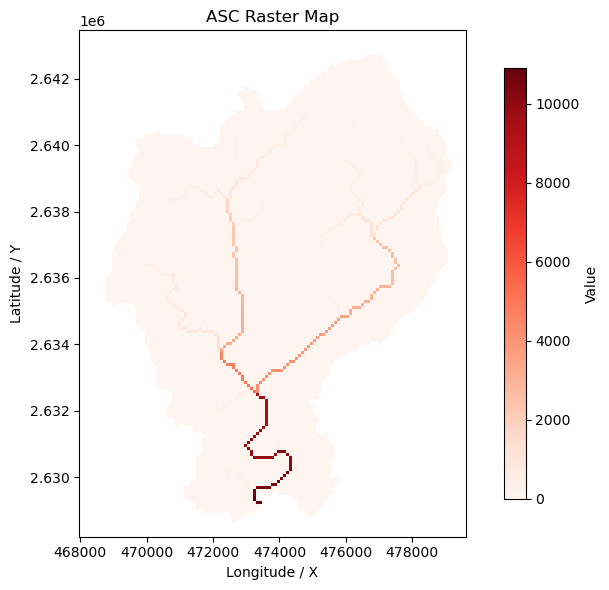

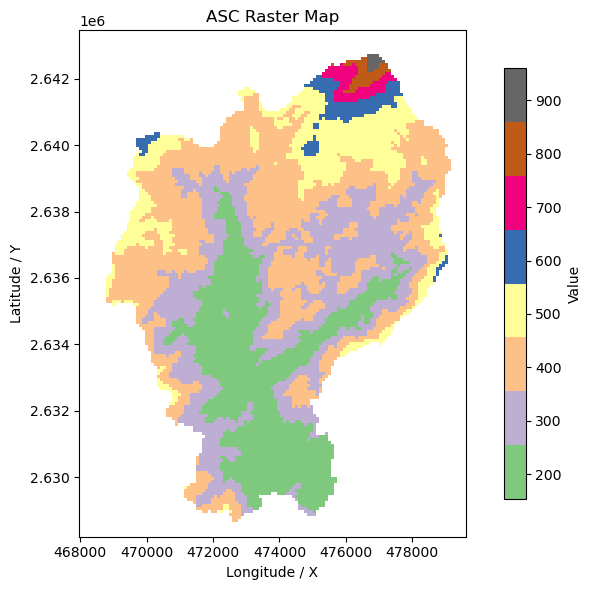

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def plot_asc(
    asc_path,
    cmap="viridis",
    title=None,
    vmin=None,
    vmax=None,
    show_colorbar=True
):
    """
    将 ESRI ASCII Grid (.asc) 绘制为地图
    
    Parameters
    ----------
    asc_path : str
        asc 文件路径
    cmap : str
        matplotlib 颜色带
    title : str
        图标题
    vmin, vmax : float
        色标范围
    show_colorbar : bool
        是否显示色标
    """

    with rasterio.open(asc_path) as src:
        data = src.read(1)
        nodata = src.nodata
        bounds = src.bounds

    # 处理 NoData
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        data,
        cmap=cmap,
        origin="upper",
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        vmin=vmin,
        vmax=vmax
    )

    if show_colorbar:
        plt.colorbar(im, shrink=0.85, label="Value")

    plt.xlabel("Longitude / X")
    plt.ylabel("Latitude / Y")
    plt.title(title or asc_path.split("/")[-1])
    plt.tight_layout()
    plt.show()


# =========================
# 示例调用
# =========================
if __name__ == "__main__":
    # plot_asc(
    #     asc_path="dem.asc",
    #     cmap="terrain",   # DEM 推荐 terrain
    #     title="ASC Raster Map"
    # )

    plot_asc(
        asc_path="flowacc.asc",
        cmap="Reds",   # DEM 推荐 terrain
        title="ASC Raster Map"
    )

    plot_asc(
        asc_path="dem.asc",
        cmap="Accent",   # DEM 推荐 terrain
        title="ASC Raster Map"
    )


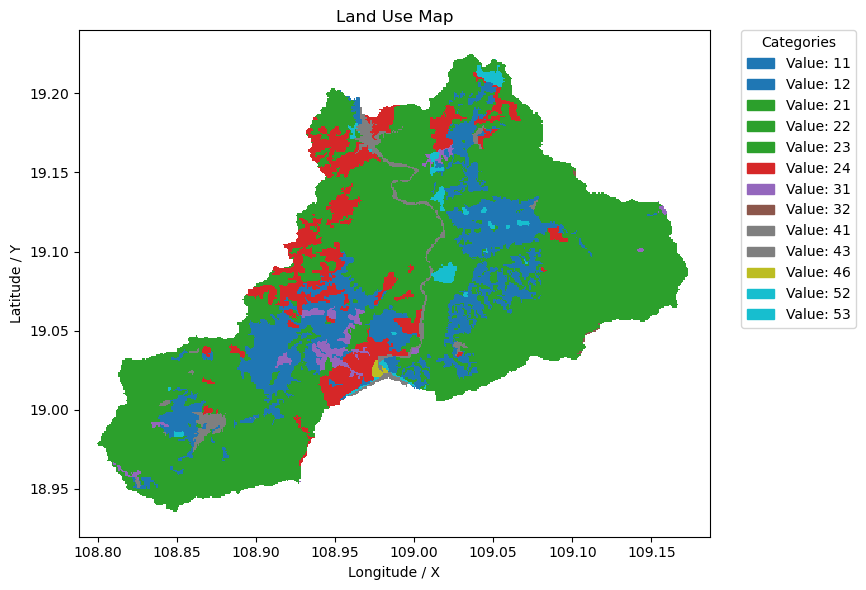

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

def plot_asc(
    asc_path,
    cmap="tab20",  # 修改默认色带，tab20 适合分类数据
    title=None,
    vmin=None,
    vmax=None,
    show_legend=True, # 将 show_colorbar 改为 show_legend 更贴切
    labels=None       # 可选：传入一个字典 {数值: "类别名称"}
):
    """
    将 ESRI ASCII Grid (.asc) 绘制为分类地图（离散图例）
    """

    with rasterio.open(asc_path) as src:
        data = src.read(1)
        nodata = src.nodata
        bounds = src.bounds

    # 1. 处理 NoData (转为 NaN)
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    # 2. 获取数据中的所有唯一值（去除 NaN）
    # 用于生成图例项
    unique_values = np.unique(data[~np.isnan(data)])
    
    # 如果数据是浮点型但代表分类，最好转为整数显示
    if unique_values.size > 0 and unique_values[0].is_integer():
        unique_values = unique_values.astype(int)

    plt.figure(figsize=(10, 6)) #稍微加宽一点给图例留位置

    # 3. 绘制图像
    # 注意：这里使用 discrete (离散) 的方式绘图
    # 如果不指定 vmin/vmax，matplotlib 会自动根据数据范围归一化
    im = plt.imshow(
        data,
        cmap=cmap,
        origin="upper",
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest' # 分类数据不要插值，否则边缘会出现不存在的颜色
    )

    # 4. 逐个构建图例 (Legend)
    if show_legend:
        legend_patches = []
        
        # 获取图像的归一化对象和色带对象，确保图例颜色与地图完全一致
        # im.norm 将数值映射到 [0, 1]
        # im.cmap 将 [0, 1] 映射到 RGBA 颜色
        
        for val in unique_values:
            # 获取该 Value 在图中对应的颜色
            color = im.cmap(im.norm(val))
            
            # 确定图例显示的文字
            if labels and val in labels:
                label_text = f"{val}: {labels[val]}"
            else:
                label_text = f"Value: {val}"
            
            # 创建图例色块
            patch = Patch(color=color, label=label_text)
            legend_patches.append(patch)

        # 将图例放在图外侧，避免遮挡地图
        plt.legend(
            handles=legend_patches, 
            bbox_to_anchor=(1.05, 1), 
            loc='upper left', 
            borderaxespad=0.,
            title="Categories"
        )

    plt.xlabel("Longitude / X")
    plt.ylabel("Latitude / Y")
    plt.title(title or asc_path.split("/")[-1])
    plt.tight_layout()
    plt.show()


# =========================
# 示例调用
# =========================
if __name__ == "__main__":
    # 假设 land.asc 里的值是 10, 20, 30...
    
    # 场景1：仅显示数值
    plot_asc(
        asc_path="rastert_landuse4.asc",
        cmap="tab10",        # 推荐使用 tab10, Set1, Paired 等离散色系
        title="Land Use Map"
    )

    # 场景2：(进阶) 如果你知道数值代表的含义，可以传入 labels
    # my_labels = {1: "Water", 2: "Forest", 3: "Urban"}
    # plot_asc(
    #     asc_path="land.asc",
    #     cmap="Set2",
    #     title="Land Use with Labels",
    #     labels=my_labels
    # )

In [9]:
import csv
from pyproj import Transformer

# ==========================================
# 1. 在这里定义你的坐标转换函数
# ==========================================
def transform(lon, lat):
    """
    坐标转换函数：将经纬度转换为平面坐标 (X, Y)
    输入: lon (经度), lat (纬度)
    输出: (x_new, y_new)
    """
    # -----------------------------------------------------------
    # 【TODO: 请在此处填入你真实的转换公式】
    # 如果你使用了 pyproj 库，代码可能长这样：
    transformer = Transformer.from_crs("epsg:4326", "epsg:4547") # 示例：WGS84 转 CGCS2000
    x, y = transformer.transform(lat, lon)
    return x, y
    # -----------------------------------------------------------
    
    # 目前仅作演示：假设只是简单的数值偏移，以免报错
    # 请务必替换这里的逻辑！
    x_new = lon   # 这里的逻辑需要你替换
    y_new = lat   # 这里的逻辑需要你替换
    
    return x_new, y_new

# ==========================================
# 2. 主处理逻辑
# ==========================================
def convert_file(input_file, output_file):
    print(f"正在读取文件: {input_file} ...")
    
    try:
        # 使用 gbk 读取 (兼容 Windows 中文), 使用 utf-8 写入
        with open(input_file, 'r', encoding='gbk') as f_in, \
             open(output_file, 'w', encoding='utf-8', newline='') as f_out:
            
            # --- 第一步：处理第一行（通常是行数统计） ---
            first_line = f_in.readline()
            f_out.write(first_line) # 原样写回
            
            # --- 第二步：设置读取器 ---
            # 假设文件是用 Tab (制表符) 分隔的。如果是空格分隔，把 delimiter='\t' 改为 delimiter=' '
            reader = csv.DictReader(f_in, delimiter='\t')
            
            # 自动清理列名中的空格 (防止 " X" 这种错误)
            if reader.fieldnames:
                reader.fieldnames = [name.strip() for name in reader.fieldnames]
            
            # 检查是否成功读取到了 X 和 Y
            if 'X' not in reader.fieldnames or 'Y' not in reader.fieldnames:
                print(f"错误：在列名中未找到 'X' 或 'Y'。检测到的列名: {reader.fieldnames}")
                print("提示：如果列名看起来连在了一起，请尝试更改 delimiter 参数。")
                return

            # --- 第三步：设置写入器 ---
            # 这里的 fieldnames 保持不变，还是 X, Y, H, Name...
            writer = csv.DictWriter(f_out, fieldnames=reader.fieldnames, delimiter='\t')
            writer.writeheader()
            
            count = 0
            # --- 第四步：循环处理数据 ---
            for row in reader:
                try:
                    # 清理数据中的空格
                    clean_row = {k.strip(): v.strip() for k, v in row.items()}
                    
                    # 获取原始经纬度 (注意：确保你的文件里 X 是经度，Y 是纬度)
                    lon = float(clean_row['X'])
                    lat = float(clean_row['Y'])
                    
                    # === 调用转换函数 ===
                    new_x, new_y = transform(lon, lat)
                    
                    # 更新行数据
                    clean_row['X'] = f"{new_x:.4f}" # 保留4位小数
                    clean_row['Y'] = f"{new_y:.4f}"
                    
                    # 写入新文件
                    writer.writerow(clean_row)
                    count += 1
                    
                except ValueError:
                    # 忽略空行或非数字行
                    continue

            print(f"转换成功！共处理 {count} 行数据。")
            print(f"结果已保存至: {output_file}")

    except UnicodeDecodeError:
        print("错误：文件编码不对。请尝试将 encoding='gbk' 改为 'utf-8' 或 'gb18030'。")
    except FileNotFoundError:
        print(f"错误：找不到文件 {input_file}")
    except Exception as e:
        print(f"发生未知错误: {e}")

# ==========================================
# 3. 执行
# ==========================================
input_filename = 'Stations.txt'
output_filename = 'Stations2.txt'

convert_file(input_filename, output_filename)

正在读取文件: Stations.txt ...
转换成功！共处理 7 行数据。
结果已保存至: Stations2.txt


In [1]:
import os
import math

def parse_asc_header(asc_path):
    """
    解析 ASC 文件头，返回元数据字典
    """
    header = {}
    try:
        with open(asc_path, 'r', encoding='ascii') as f:
            for _ in range(6):
                line = f.readline().strip().split()
                if not line: break
                key = line[0].lower()
                val = line[1]
                
                # 尝试转换为数字
                try:
                    if '.' in val:
                        header[key] = float(val)
                    else:
                        header[key] = int(val)
                except ValueError:
                    header[key] = val
    except Exception as e:
        print(f"[Error] 无法读取文件头: {e}")
        return None
    return header

def calculate_grid_coords(header, geo_x, geo_y):
    """
    核心计算逻辑：将地理坐标转换为网格行列号
    """
    cellsize = header.get('cellsize')
    nrows = header.get('nrows')
    ncols = header.get('ncols')
    
    # 1. 确定 X 原点 (左边)
    xll = header.get('xllcorner')
    if xll is None:
        xll = header.get('xllcenter') - 0.5 * cellsize
        
    # 2. 确定 Y 原点 (顶部)
    # ASC文件通常记录的是【左下角】(yllcorner)，而网格索引(0,0)通常是【左上角】
    # 所以 Top_Y = Bottom_Y + N_Rows * CellSize
    yll = header.get('yllcorner')
    if yll is None:
        yll = header.get('yllcenter') - 0.5 * cellsize
        
    top_y = yll + nrows * cellsize
    
    # 3. 计算逻辑
    # Col = (Geo_X - Left_X) / CellSize
    # Row = (Top_Y - Geo_Y) / CellSize  (注意 Y 轴方向是相反的)
    
    col_float = (geo_x - xll) / cellsize
    row_float = (top_y - geo_y) / cellsize
    
    col = int(col_float)
    row = int(row_float)
    
    # 4. 边界检查
    is_valid = True
    if col < 0 or col >= ncols:
        is_valid = False
    if row < 0 or row >= nrows:
        is_valid = False
        
    return {
        'row': row,
        'col': col,
        'row_raw': row_float, # 保留小数供参考
        'col_raw': col_float,
        'valid': is_valid,
        'x_origin': xll,
        'y_top': top_y
    }

def main():
    print("="*40)
    print("      ASC 坐标转换器 (Geo -> Grid)")
    print("="*40)
    
    # 1. 获取文件路径
    while True:
        asc_path = "F:\流溪河模型\Liuxihe_python\Input_2\Spatial\dem.asc"
        if os.path.exists(asc_path):
            break
        print("❌ 文件不存在，请重新输入。")
        
    # 2. 解析头文件
    print(f"\n正在读取头文件: {os.path.basename(asc_path)} ...")
    header = parse_asc_header(asc_path)
    if not header:
        return
        
    print("-" * 30)
    print(f"元数据信息:")
    print(f"  - Rows: {header.get('nrows')}")
    print(f"  - Cols: {header.get('ncols')}")
    print(f"  - CellSize: {header.get('cellsize')}")
    print(f"  - XllCorner: {header.get('xllcorner', 'N/A')}")
    print(f"  - YllCorner: {header.get('yllcorner', 'N/A')}")
    print("-" * 30)
    
    # 3. 循环输入坐标
    print("\n💡 输入 'q' 退出程序")
    while True:
        try:
            user_input = input("\n请输入坐标 (格式: X Y 或 X,Y): ")
            if user_input.lower() == 'q':
                break
                
            # 处理逗号或空格分隔
            user_input = user_input.replace(',', ' ')
            parts = user_input.split()
            
            if len(parts) != 2:
                print("⚠️ 格式错误，请输入两个数字，用空格隔开。")
                continue
                
            geo_x = float(parts[0])
            geo_y = float(parts[1])
            
            # 计算
            res = calculate_grid_coords(header, geo_x, geo_y)
            
            # 输出结果
            print(f"\n📍 转换结果:")
            print(f"   输入坐标: X={geo_x}, Y={geo_y}")
            
            if res['valid']:
                print(f"   ✅ 网格坐标: Row={res['row']}, Col={res['col']}")
                print(f"      (用于代码: self.Q_t[{res['row']}, {res['col']}])")
            else:
                print(f"   ❌ 坐标超出地图范围！")
                print(f"      计算值: Row={res['row']}, Col={res['col']}")
                print(f"      范围是: Row[0~{header['nrows']-1}], Col[0~{header['ncols']-1}]")
                
        except ValueError:
            print("⚠️ 输入无效，请输入数字。")
        except Exception as e:
            print(f"❌ 发生错误: {e}")

if __name__ == "__main__":
    main()

      ASC 坐标转换器 (Geo -> Grid)

正在读取头文件: dem.asc ...
------------------------------
元数据信息:
  - Rows: 370
  - Cols: 449
  - CellSize: 90
  - XllCorner: -48373.14048034
  - YllCorner: 2101423.9804917
------------------------------

💡 输入 'q' 退出程序

📍 转换结果:
   输入坐标: X=-29836.0486, Y=2131473.7591
   ✅ 网格坐标: Row=36, Col=205
      (用于代码: self.Q_t[36, 205])

📍 转换结果:
   输入坐标: X=-28930.7118, Y=2111556.682
   ✅ 网格坐标: Row=257, Col=216
      (用于代码: self.Q_t[257, 216])

📍 转换结果:
   输入坐标: X=-32111.5548, Y=2114870.662
   ✅ 网格坐标: Row=220, Col=180
      (用于代码: self.Q_t[220, 180])

📍 转换结果:
   输入坐标: X=-21321.0002, Y=2122784.6925
   ✅ 网格坐标: Row=132, Col=300
      (用于代码: self.Q_t[132, 300])

📍 转换结果:
   输入坐标: X=-14378.3823, Y=2118033.9567
   ✅ 网格坐标: Row=185, Col=377
      (用于代码: self.Q_t[185, 377])

📍 转换结果:
   输入坐标: X=-39169.2246, Y=2108407.3417
   ✅ 网格坐标: Row=292, Col=102
      (用于代码: self.Q_t[292, 102])

📍 转换结果:
   输入坐标: X=-22978.8607, Y=2127609.6782
   ✅ 网格坐标: Row=79, Col=282
      (用于代码: self.Q_t[79, 282])
